# Compare aFRR VWAP vs Average Activation Price

Objective: validate that manually derived hourly VWAP from 15-minute
Regelleistung data is the most robust work-price signal for modeling.

In [23]:
from pathlib import Path
import os
import requests
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

True

## 1) ENTSO-E CBMP failure reproduction (why not CBMP)

In [24]:
token = os.getenv("ENTSOE_API_TOKEN") or os.getenv("ENTSOE_API_KEY")
if not token:
    print("ENTSOE token missing (ENTSOE_API_TOKEN/ENTSOE_API_KEY).")
else:
    base_url = "https://web-api.tp.entsoe.eu/api"
    # TenneT SCA, one-month request
    params = {
        "securityToken": token,
        "documentType": "A84",
        "processType": "A67",
        "businessType": "A96",
        "Standard_MarketProduct": "A01",
        "controlArea_Domain": "10YDE-EON------1",
        "periodStart": "202401010000",
        "periodEnd": "202402010000",
    }
    try:
        r = requests.get(base_url, params=params, timeout=90)
        r.raise_for_status()
        print("CBMP request unexpectedly succeeded. Status:", r.status_code)
        print("Response head:")
        print(r.text[:400])
    except Exception as exc:
        print("CBMP request failed as expected:")
        print(type(exc).__name__, str(exc))

CBMP request failed as expected:
ReadTimeout HTTPSConnectionPool(host='web-api.tp.entsoe.eu', port=443): Read timed out. (read timeout=90)


**Conclusion:** The CBMP via ENTSO-E was rejected due to persistent API
timeouts and non-standard 4-second resolutions (PT4S) from other German TSOs.

## 2) Load 15-minute Regelleistung price/volume and compute hourly VWAP

In [25]:
# Robustly locate the project data file by walking up parent directories.
REL = Path("data/raw/regelleistung_15min/afrr_price_volume_15min.parquet")
search_roots = [Path.cwd(), *Path.cwd().parents]
path_15m = None
for root in search_roots:
    candidate = (root / REL).resolve()
    if candidate.exists():
        path_15m = candidate
        break

if path_15m is None:
    tried = "\n".join(str((r / REL).resolve()) for r in search_roots)
    raise FileNotFoundError("Missing 15-min parquet. Tried:\n" + tried)

raw = pl.read_parquet(path_15m).with_columns(
    pl.col("timestamp_utc").cast(pl.Datetime(time_unit="us", time_zone="UTC"), strict=False)
).sort("timestamp_utc")


def first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

vol_pos_col = first_existing(raw.columns, ["afrr_activated_mw_pos", "activated_volume_pos_mw", "abgerufene_arbeit_pos"])
price_pos_col = first_existing(
    raw.columns,
    [
        "afrr_avg_activation_price_pos",
        "afrr_activation_avg_price_pos",
        "afrr_marginal_activation_price_pos",
        "afrr_activation_marginal_price_pos",
        "arbeitspreis_pos",
    ],
)
official_avg_pos_col = first_existing(
    raw.columns,
    ["afrr_avg_activation_price_pos", "afrr_activation_avg_price_pos", "durchschnittlicher_arbeitspreis_pos"],
)

if not vol_pos_col or not price_pos_col:
    raise KeyError(
        f"Missing required columns. volume={vol_pos_col}, price={price_pos_col}. "
        f"Available: {raw.columns}"
    )

PICASSO_CUTOFF = pd.Timestamp("2022-06-22T22:00:00Z")

base = (
    raw.select([
        "timestamp_utc",
        pl.col(vol_pos_col).cast(pl.Float64, strict=False).alias("activated_volume_pos_mw"),
        pl.col(price_pos_col).cast(pl.Float64, strict=False).alias("activation_price_pos_raw"),
        (
            pl.col(official_avg_pos_col).cast(pl.Float64, strict=False).alias("official_avg_activation_price_pos")
            if official_avg_pos_col is not None
            else pl.lit(None).cast(pl.Float64).alias("official_avg_activation_price_pos")
        ),
    ])
    .with_columns(pl.col("timestamp_utc").dt.truncate("1h").alias("hour_utc"))
    .with_columns(
        pl.when(pl.col("timestamp_utc") < pl.lit(PICASSO_CUTOFF))
        .then(
            pl.col("activation_price_pos_raw")
            .forward_fill()
            .over(pl.col("timestamp_utc").dt.truncate("1h"))
        )
        .otherwise(pl.col("activation_price_pos_raw"))
        .alias("activation_price_pos_ffill")
    )
    .with_columns(
        (pl.col("activated_volume_pos_mw") * pl.col("activation_price_pos_ffill")).alias("weighted_cost_pos")
    )
)

hourly = (
    base.group_by("hour_utc")
    .agg([
        pl.sum("weighted_cost_pos").alias("sum_weighted_pos"),
        pl.sum("activated_volume_pos_mw").alias("sum_volume_pos"),
        pl.mean("activation_price_pos_raw").alias("simple_mean_price_pos"),
        pl.mean("official_avg_activation_price_pos").alias("official_avg_price_pos"),
    ])
    .with_columns(
        pl.when(pl.col("sum_volume_pos").is_null() | (pl.col("sum_volume_pos") == 0))
        .then(pl.lit(float("nan")))
        .otherwise(pl.col("sum_weighted_pos") / pl.col("sum_volume_pos"))
        .alias("hourly_vwap_pos")
    )
    .sort("hour_utc")
)

comparison_15m = (
    base.join(
        hourly.select(["hour_utc", "hourly_vwap_pos", "simple_mean_price_pos", "official_avg_price_pos"]),
        on="hour_utc",
        how="left",
    )
    .sort("timestamp_utc")
)

comparison_15m.head()


timestamp_utc,activated_volume_pos_mw,activation_price_pos_raw,official_avg_activation_price_pos,hour_utc,activation_price_pos_ffill,weighted_cost_pos,hourly_vwap_pos,simple_mean_price_pos,official_avg_price_pos
"datetime[μs, UTC]",f64,f64,f64,"datetime[μs, UTC]",f64,f64,f64,f64,f64
2020-11-30 23:00:00 UTC,null,2733.73,2733.73,2020-11-30 23:00:00 UTC,2733.73,null,NaN,2733.73,2733.73
2020-12-01 00:00:00 UTC,201.924,2733.73,2733.73,2020-12-01 00:00:00 UTC,2733.73,552005.69652,2733.73,2733.73,2733.73
2020-12-01 00:15:00 UTC,113.628,null,null,2020-12-01 00:00:00 UTC,2733.73,310628.27244,2733.73,2733.73,2733.73
2020-12-01 00:30:00 UTC,291.524,null,null,2020-12-01 00:00:00 UTC,2733.73,796947.90452,2733.73,2733.73,2733.73
2020-12-01 00:45:00 UTC,5.716,null,null,2020-12-01 00:00:00 UTC,2733.73,15626.00068,2733.73,2733.73,2733.73


## 3) Validation windows (6h each)

In [26]:
def window_table(df: pl.DataFrame, start_utc: str, hours: int = 6) -> pd.DataFrame:
    start_ts = pd.Timestamp(start_utc)
    end_ts = start_ts + pd.Timedelta(hours=hours)
    w = (
        df.filter(
            (pl.col("timestamp_utc") >= pl.lit(start_ts))
            & (pl.col("timestamp_utc") < pl.lit(end_ts))
        )
        .select([
            "timestamp_utc",
            "activated_volume_pos_mw",
            "activation_price_pos_raw",
            "activation_price_pos_ffill",
            "official_avg_activation_price_pos",
            "hourly_vwap_pos",
            "simple_mean_price_pos",
            "official_avg_price_pos",
        ])
        .sort("timestamp_utc")
    )
    return w.to_pandas().set_index("timestamp_utc")

pre = window_table(comparison_15m, "2021-03-01T10:00:00Z", hours=6)
post = window_table(comparison_15m, "2022-08-01T10:00:00Z", hours=6)

print("Pre-PICASSO: 2021-03-01 10:00-16:00 UTC")
display(pre)

print("Post-PICASSO: 2022-08-01 10:00-16:00 UTC")
display(post)


Pre-PICASSO: 2021-03-01 10:00-16:00 UTC


,activated_volume_pos_mw,activation_price_pos_raw,activation_price_pos_ffill,official_avg_activation_price_pos,hourly_vwap_pos,simple_mean_price_pos,official_avg_price_pos
timestamp_utc,,,,,,,
2021-03-01 10:00:00+00:00,46.272,2554.23,2554.23,2554.23,2554.23,2554.23,2554.23
2021-03-01 10:15:00+00:00,0.780,NaN,2554.23,NaN,2554.23,2554.23,2554.23
2021-03-01 10:30:00+00:00,6.404,NaN,2554.23,NaN,2554.23,2554.23,2554.23
2021-03-01 10:45:00+00:00,2.044,NaN,2554.23,NaN,2554.23,2554.23,2554.23
2021-03-01 11:00:00+00:00,74.340,460.21,460.21,460.21,460.21,460.21,460.21
2021-03-01 11:15:00+00:00,9.624,NaN,460.21,NaN,460.21,460.21,460.21
2021-03-01 11:30:00+00:00,16.248,NaN,460.21,NaN,460.21,460.21,460.21
2021-03-01 11:45:00+00:00,1.324,NaN,460.21,NaN,460.21,460.21,460.21
2021-03-01 12:00:00+00:00,263.752,460.21,460.21,460.21,460.21,460.21,460.21


Post-PICASSO: 2022-08-01 10:00-16:00 UTC


,activated_volume_pos_mw,activation_price_pos_raw,activation_price_pos_ffill,official_avg_activation_price_pos,hourly_vwap_pos,simple_mean_price_pos,official_avg_price_pos
timestamp_utc,,,,,,,
2022-08-01 10:00:00+00:00,352.536,1273.71,1273.71,1273.71,1072.074616,975.5725,975.5725
2022-08-01 10:15:00+00:00,160.332,892.14,892.14,892.14,1072.074616,975.5725,975.5725
2022-08-01 10:30:00+00:00,6.984,879.36,879.36,879.36,1072.074616,975.5725,975.5725
2022-08-01 10:45:00+00:00,190.184,857.08,857.08,857.08,1072.074616,975.5725,975.5725
2022-08-01 11:00:00+00:00,231.264,844.96,844.96,844.96,884.144017,899.7025,899.7025
2022-08-01 11:15:00+00:00,151.532,915.50,915.50,915.50,884.144017,899.7025,899.7025
2022-08-01 11:30:00+00:00,62.488,952.88,952.88,952.88,884.144017,899.7025,899.7025
2022-08-01 11:45:00+00:00,11.496,885.47,885.47,885.47,884.144017,899.7025,899.7025
2022-08-01 12:00:00+00:00,0.688,3111.15,3111.15,3111.15,1393.581679,1560.8025,1560.8025


## 4) Plot: hourly VWAP vs simple hourly mean

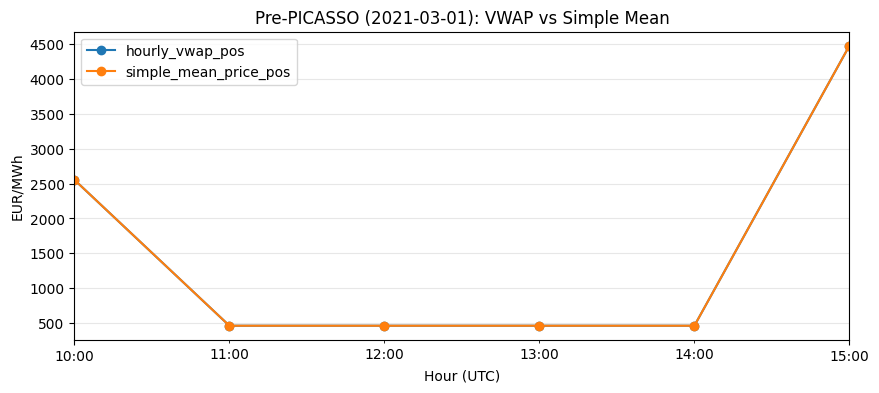

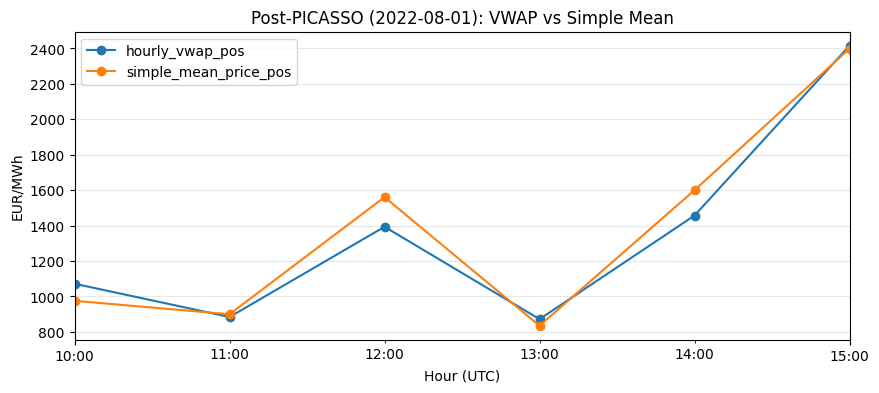

In [27]:
def plot_window(df_win: pd.DataFrame, title: str):
    hourly = (
        df_win
        .assign(hour=lambda x: x.index.floor("1h"))
        .groupby("hour")[["hourly_vwap_pos", "simple_mean_price_pos"]]
        .first()
        .sort_index()
    )
    ax = hourly.plot(marker="o", figsize=(10, 4))
    ax.set_title(title)
    ax.set_ylabel("EUR/MWh")
    ax.set_xlabel("Hour (UTC)")
    ax.grid(True, alpha=0.3)
    plt.show()

plot_window(pre, "Pre-PICASSO (2021-03-01): VWAP vs Simple Mean")
plot_window(post, "Post-PICASSO (2022-08-01): VWAP vs Simple Mean")